# ACE Sample Band Comparison: Fe-56 Elastic Angular Distributions

2x2 comparison of Fe-56 elastic scattering angular distributions from ACE files:
- **Top row**: JEFF-4.0 and JENDL-5 MC sample curves + EXFOR
- **Bottom row**: This work (orig) and This work (new) MC sample curves + EXFOR

All panels use ACE PDF data (pre-extracted to parquet) scaled by c0 from EXFOR:
`dσ/dΩ = 2 × c0 × PDF(μ)`

**Workflow**: Run cells 1-3 once (heavy loading), then change `TARGET_ENERGY_MEV` in cell 5 and re-run from there.

## 1. Configuration

In [1]:
# ============================================================================
# USER CONFIGURABLE PARAMETERS
# ============================================================================

# -- ACE parquet files (from extract_ace_angular_data.py) --------------------
PARQUET_DIR = '/share_snc/snc/JuanMonleon/EXFOR/ace_angular_parquet'

PARQUET_FILES = {
    'JEFF-4.0':          f'{PARQUET_DIR}/jeff40_ace_angular.parquet',
    'JENDL-5':           f'{PARQUET_DIR}/jendl5_ace_angular.parquet',
    'This work (orig)':  f'{PARQUET_DIR}/this_work_orig_ace_angular.parquet',
    'This work (new)':   f'{PARQUET_DIR}/this_work_new_ace_angular.parquet',
}
MU_GRID_FILES = {
    'JEFF-4.0':          f'{PARQUET_DIR}/jeff40_mu_grid.npy',
    'JENDL-5':           f'{PARQUET_DIR}/jendl5_mu_grid.npy',
    'This work (orig)':  f'{PARQUET_DIR}/this_work_orig_mu_grid.npy',
    'This work (new)':   f'{PARQUET_DIR}/this_work_new_mu_grid.npy',
}

N_MU_POINTS = 200
MT_NUMBER = 2

# -- EXFOR configuration ----------------------------------------------------
EXFOR_DB_PATH = '/share_snc/snc/JuanMonleon/EXFOR/x4_iron_angular.db'
TARGET_ZAIDS  = [26056, 26000]

SUPPLEMENTARY_JSON_FILES = [
    '/share_snc/snc/JuanMonleon/EXFOR/data_v1/27673002.json',
]
EXCLUDE_EXPERIMENTS = ["32246002"]
MIN_RELATIVE_UNCERTAINTY = 0.03

# -- Normalization rules -----------------------------------------------------
KINNEY_SUBENTRY      = "10571002"
SMITH_SUBENTRY       = "10886002"
ENERGY_THRESHOLD_MEV = 2.5

# -- Physics parameters ------------------------------------------------------
M_PROJ_U = 1.008665
M_TARG_U = 55.93494
DELTA_T_NS    = 5.0
FLIGHT_PATH_M = 27.037

# -- Plot settings -----------------------------------------------------------
PLOT_YSCALE      = 'log'
N_SAMPLES_PLOT   = 100
SAMPLE_ALPHA     = 0.08
EXFOR_PLOT_N_SIGMA   = 2.0
EXFOR_PLOT_MIN_ALPHA = 0.3

FIGURE_DPI = 300
FIGSIZE_2x2 = (10, 8)

FONTSIZES = {'axes_label': 10, 'tick_label': 9, 'legend': 8, 'subplot_title': 11}

CASE_COLORS = {
    'JEFF-4.0':          'tab:blue',
    'JENDL-5':           'tab:green',
    'This work (orig)':  'tab:red',
    'This work (new)':   'tab:orange',
}

## 2. Imports

In [2]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Ensure kika is on the path
_kika_path = Path().absolute().parent.parent.parent.parent
if str(_kika_path) not in sys.path:
    sys.path.insert(0, str(_kika_path))

from kika.exfor import read_all_exfor
import kika.exfor as exfor
from kika.plotting.styles import _get_color_palette

from scripts.exfor_utils import (
    build_exfor_cache_from_objects,
    filter_exfor_with_energy_bin,
    filter_exfor_with_kernel_weights,
)
from scripts.resample_AD import (
    compute_energy_resolution_tof as compute_sigma_E,
    sample_legendre_coefficients,
)

exfor.configure(db_path=EXFOR_DB_PATH)

plt.rcParams['figure.dpi'] = FIGURE_DPI
KIKA_COLORS = _get_color_palette('light')
EXFOR_MARKERS = ['o', 's', '^', 'v', 'D', 'p', 'h', '*', 'X', '<', '>']

print("Imports OK")

Imports OK


## 3. Load Heavy Data (run once)

In [3]:
# Load parquet files
print("Loading ACE angular parquet files...")
ace_parquet = {}
for key, path in PARQUET_FILES.items():
    try:
        df = pd.read_parquet(path)
        ace_parquet[key] = df
        n_samples = df['sample_idx'].nunique()
        n_energies = df['energy_idx'].nunique()
        print(f"  {key}: {n_samples} samples, {n_energies} energies")
    except FileNotFoundError:
        print(f"  {key}: NOT FOUND at {path}")

# Define mu grid and pdf columns
mu_grid = np.linspace(-1, 1, N_MU_POINTS)
pdf_cols = [f'pdf_{j:03d}' for j in range(N_MU_POINTS)]

# Load EXFOR database
print("\nLoading EXFOR data from database...")
exfor_dict = read_all_exfor(
    target=TARGET_ZAIDS, mt=MT_NUMBER, source="database",
    group_by_energy=False,
    supplementary_json_files=SUPPLEMENTARY_JSON_FILES,
    exclude_experiments=EXCLUDE_EXPERIMENTS,
)
exfor_objects = list(exfor_dict.values())
exfor_cache, sorted_exfor_energies = build_exfor_cache_from_objects(
    exfor_objects, exclude_experiments=EXCLUDE_EXPERIMENTS,
)
print(f"  Datasets        : {len(exfor_objects)}")
print(f"  Unique energies : {len(sorted_exfor_energies)}")
print(f"  Energy range    : [{min(sorted_exfor_energies):.4f}, {max(sorted_exfor_energies):.4f}] MeV")
print("\nAll data loaded.")

Loading ACE angular parquet files...
  JEFF-4.0: 100 samples, 4027 energies
  JENDL-5: 100 samples, 1860 energies
  This work (orig): 100 samples, 3979 energies
  This work (new): 100 samples, 3979 energies

Loading EXFOR data from database...
  Datasets        : 119
  Unique energies : 22687
  Energy range    : [0.0350, 96.0000] MeV

All data loaded.


## 4. Helper Functions

In [4]:
def select_energy_from_ace_parquet(df, target_energy_mev):
    """Select the closest energy in the ACE parquet to the target.
    
    Returns
    -------
    dict with energy_idx, closest_energy_mev, bin_lower, bin_upper
    """
    # Get unique energies from sample 1
    sample1 = df[df['sample_idx'] == 1].sort_values('energy_idx')
    energies = sample1['energy_mev'].values
    idx_in_sample = int(np.argmin(np.abs(energies - target_energy_mev)))
    energy_idx = sample1.iloc[idx_in_sample]['energy_idx']
    closest_mev = energies[idx_in_sample]
    
    # Compute bin boundaries
    if idx_in_sample > 0:
        bin_lower = (energies[idx_in_sample - 1] + closest_mev) / 2
    else:
        bin_lower = 0.0
    if idx_in_sample < len(energies) - 1:
        bin_upper = (closest_mev + energies[idx_in_sample + 1]) / 2
    else:
        bin_upper = float('inf')
    
    return dict(energy_idx=int(energy_idx), closest_energy_mev=closest_mev,
                bin_lower=bin_lower, bin_upper=bin_upper)


def filter_exfor_for_case(case_data, post_filter_subentry=None):
    """Filter EXFOR for a given energy bin, optionally restricting to one subentry."""
    df, exp_info, kw, diag = filter_exfor_with_energy_bin(
        exfor_cache=exfor_cache,
        sorted_energies=sorted_exfor_energies,
        bin_lower_mev=case_data['bin_lower'],
        bin_upper_mev=case_data['bin_upper'],
        target_energy_mev=case_data['closest_energy_mev'],
        m_proj_u=M_PROJ_U, m_targ_u=M_TARG_U,
        dedupe_per_experiment=True,
        exclude_experiments=EXCLUDE_EXPERIMENTS,
        min_relative_uncertainty=MIN_RELATIVE_UNCERTAINTY,
        normalize_by_n_points=True,
        max_experiment_weight_fraction=0.5,
    )
    if not df.empty and 'experiment_id' not in df.columns:
        df['experiment_id'] = df['entry'] + '/' + df['subentry']
    if post_filter_subentry is not None and not df.empty:
        entry_str = post_filter_subentry[:5]
        sub_str   = post_filter_subentry[5:]
        mask = (df['entry'] == entry_str) & (df['subentry'] == sub_str)
        if mask.any():
            df  = df[mask].reset_index(drop=True)
            kw  = kw[mask.values] if kw is not None else None
            exp_info = [e for e in exp_info
                        if e.get('entry') == entry_str and e.get('subentry') == sub_str]
        else:
            print(f"    WARNING: subentry {entry_str}/{sub_str} not found; using all data")
    return df, exp_info, kw


def fit_c0_from_exfor(exfor_df, kernel_weights, L_max=6):
    """Fit EXFOR data to extract c0 (isotropic cross section / 4pi)."""
    if exfor_df is None or exfor_df.empty or len(exfor_df) < 2:
        print("  WARNING: too few EXFOR points for c0 fit")
        return None
    coef_df, fit_info = sample_legendre_coefficients(
        df=exfor_df, value_col="value", unc_col="unc", mu_col="mu",
        degree=L_max, n_samples=1,
        external_weights=kernel_weights,
        ridge_lambda=1e-6, rescale_unc_by_chi2=True,
    )
    c0 = coef_df['c0'].values[0]
    print(f"  c0 (EXFOR) = {c0:.6f} b/sr, chi2_red = {fit_info['chi2_red']:.2f}")
    return c0


def compute_ace_sample_curves(parquet_df, energy_idx, c0, pdf_cols):
    """Compute d\u03c3/d\u03a9 = 2 * c0 * PDF for all samples at a given energy.
    
    Returns
    -------
    curves : np.ndarray, shape (n_samples, N_MU_POINTS)
    """
    rows = parquet_df[parquet_df['energy_idx'] == energy_idx]
    pdf_matrix = rows[pdf_cols].values.astype(np.float64)
    curves = 2.0 * c0 * pdf_matrix
    return curves


def _plot_ext_exfor(ax, ext_data):
    """Plot extended EXFOR (nearby in grey + in-bin in color) on axis."""
    if ext_data is None:
        return
    edf = ext_data['ext_df']
    vmap = ext_data['exp_visual_map']
    lmap = ext_data['exp_label_map']
    _nearby_placed = False
    df_near = edf[~edf['in_bin']]
    for eid in df_near['experiment_id'].unique():
        mask = df_near['experiment_id'] == eid
        df_exp = df_near[mask]
        _, marker = vmap[eid]
        avg_alpha = df_exp['plot_alpha'].median()
        lbl = (f'Nearby EXFOR ({EXFOR_PLOT_N_SIGMA:.0f}$\\sigma_E$ window)'
               if not _nearby_placed else None)
        _nearby_placed = True
        ax.errorbar(df_exp['mu'], df_exp['value'], yerr=df_exp['unc'],
                    fmt=marker, color='0.55', label=lbl,
                    capsize=2, markersize=3, alpha=avg_alpha,
                    markerfacecolor='none', markeredgewidth=0.6, markeredgecolor='0.55',
                    elinewidth=0.5, ecolor='0.7')
    df_in = edf[edf['in_bin']]
    for eid in df_in['experiment_id'].unique():
        mask = df_in['experiment_id'] == eid
        df_exp = df_in[mask]
        color, marker = vmap[eid]
        ax.errorbar(df_exp['mu'], df_exp['value'], yerr=df_exp['unc'],
                    fmt=marker, color=color, label=lmap.get(eid, eid),
                    capsize=2, markersize=4, alpha=0.9, markeredgewidth=0.5)


def _plot_sample_panel(ax, curves, mu, color, label):
    """Plot MC sample curves on an axis (all samples equal weight, no nominal)."""
    for i in range(len(curves)):
        ax.plot(mu, curves[i], color=color, alpha=SAMPLE_ALPHA, lw=0.5,
                label='MC samples' if i == 0 else None)


print("Helper functions defined.")

Helper functions defined.


## 5. Set Target Energy -- Re-run from here

In [8]:
TARGET_ENERGY_MEV = 1.00

## 6. Energy-Dependent Processing

In [9]:
# --- Select energy from each ACE parquet ---
print("Selecting energy from ACE parquets...")
case_data = {}
for key in ace_parquet:
    info = select_energy_from_ace_parquet(ace_parquet[key], TARGET_ENERGY_MEV)
    case_data[key] = info
    print(f"  {key}: E={info['closest_energy_mev']:.6f} MeV, "
          f"idx={info['energy_idx']}, bin=[{info['bin_lower']:.6f}, {info['bin_upper']:.6f}]")

# --- Common energy bin (union of all sets) ---
common_bin_lower = min(d['bin_lower'] for d in case_data.values())
common_bin_upper = max(d['bin_upper'] for d in case_data.values())
common_target_energy = list(case_data.values())[0]['closest_energy_mev']
common_data = dict(bin_lower=common_bin_lower, bin_upper=common_bin_upper,
                   closest_energy_mev=common_target_energy)
print(f"  Common bin: [{common_bin_lower:.6f}, {common_bin_upper:.6f}] MeV")

# --- Filter EXFOR ---
sub = KINNEY_SUBENTRY if TARGET_ENERGY_MEV < ENERGY_THRESHOLD_MEV else SMITH_SUBENTRY
print(f"\nNormalization subentry: {sub}")

# JEFF/JENDL: use normalization subentry for c0
print("\nFiltering EXFOR ...")
jeff_exfor,  jeff_exp_info,  jeff_kw  = filter_exfor_for_case(case_data['JEFF-4.0'],  sub)
jendl_exfor, jendl_exp_info, jendl_kw = filter_exfor_for_case(case_data['JENDL-5'],  sub)
print(f"  JEFF-4.0: {len(jeff_exfor)} pts, JENDL-5: {len(jendl_exfor)} pts")

# This work: all in-bin EXFOR
shared_exfor, shared_exp_info, shared_kw = filter_exfor_for_case(common_data, None)
print(f"  All in-bin EXFOR: {len(shared_exfor)} pts")

# --- Extended EXFOR for plotting ---
print("\nBuilding extended EXFOR ...")
sigma_E_mev = compute_sigma_E(
    common_target_energy, delta_t_ns=DELTA_T_NS, flight_path_m=FLIGHT_PATH_M)
ext_df, ext_exp_info, ext_kw, _ = filter_exfor_with_kernel_weights(
    exfor_cache=exfor_cache, sorted_energies=sorted_exfor_energies,
    energy_mev=common_target_energy, sigma_E_mev=sigma_E_mev,
    n_sigma=EXFOR_PLOT_N_SIGMA, m_proj_u=M_PROJ_U, m_targ_u=M_TARG_U,
    bin_lower_mev=common_bin_lower, bin_upper_mev=common_bin_upper,
    use_overlap_weights=False, dedupe_per_experiment=False,
    normalize_by_n_points=False, exclude_experiments=EXCLUDE_EXPERIMENTS,
    min_relative_uncertainty=MIN_RELATIVE_UNCERTAINTY, max_experiment_weight_fraction=1.0)

ext_exfor_data = None
if not ext_df.empty:
    if 'experiment_id' not in ext_df.columns:
        ext_df['experiment_id'] = ext_df['entry'] + '/' + ext_df['subentry']
    ext_df['in_bin'] = (
        (ext_df['exfor_energy_mev'] >= common_bin_lower) &
        (ext_df['exfor_energy_mev'] <= common_bin_upper))
    target_e = common_target_energy
    for eid in ext_df.loc[ext_df['in_bin'], 'experiment_id'].unique():
        exp_in_bin = (ext_df['experiment_id'] == eid) & ext_df['in_bin']
        unique_energies = ext_df.loc[exp_in_bin, 'exfor_energy_mev'].unique()
        if len(unique_energies) > 1:
            closest_energy = unique_energies[np.argmin(np.abs(unique_energies - target_e))]
            demote = exp_in_bin & (ext_df['exfor_energy_mev'] != closest_energy)
            ext_df.loc[demote, 'in_bin'] = False
    max_kw = ext_kw.max() if len(ext_kw) > 0 else 1.0
    norm_kw = ext_kw / max_kw if max_kw > 0 else np.ones_like(ext_kw)
    ext_df['plot_alpha'] = EXFOR_PLOT_MIN_ALPHA + norm_kw * (0.9 - EXFOR_PLOT_MIN_ALPHA)
    ext_df.loc[ext_df['in_bin'], 'plot_alpha'] = 0.9
    all_exp_ids = ext_df['experiment_id'].unique()
    in_bin_exp_ids = ext_df.loc[ext_df['in_bin'], 'experiment_id'].unique().tolist()
    nearby_only_exp_ids = [e for e in all_exp_ids if e not in in_bin_exp_ids]
    ordered_exp_ids = in_bin_exp_ids + nearby_only_exp_ids
    exp_visual_map = {}
    for i, eid in enumerate(ordered_exp_ids):
        exp_visual_map[eid] = (KIKA_COLORS[i % len(KIKA_COLORS)],
                               EXFOR_MARKERS[i % len(EXFOR_MARKERS)])
    exp_label_map = {}
    for info in ext_exp_info:
        eid = f"{info.get('entry', '')}/{info.get('subentry', '')}"
        exp_label_map[eid] = f"{info.get('author', eid)} ({info.get('year', '?')})"
    for eid in ordered_exp_ids:
        if eid not in exp_label_map:
            exp_label_map[eid] = eid
    ext_exfor_data = dict(
        ext_df=ext_df, exp_visual_map=exp_visual_map,
        exp_label_map=exp_label_map, in_bin_set=set(in_bin_exp_ids))
    n_nearby = (~ext_df['in_bin']).sum()
    n_inbin = ext_df['in_bin'].sum()
    print(f"  Extended: {n_inbin} in-bin + {n_nearby} nearby")

# --- Fit c0 from EXFOR for each set ---
print("\nFitting c0 from EXFOR ...")
c0_values = {}

# JEFF/JENDL: use normalization subentry
print("JEFF-4.0:")
c0_values['JEFF-4.0'] = fit_c0_from_exfor(jeff_exfor, jeff_kw)
print("JENDL-5:")
c0_values['JENDL-5'] = fit_c0_from_exfor(jendl_exfor, jendl_kw)

# This work: all in-bin EXFOR
print("This work (orig):")
c0_values['This work (orig)'] = fit_c0_from_exfor(shared_exfor, shared_kw)
print("This work (new):")
c0_values['This work (new)'] = fit_c0_from_exfor(shared_exfor, shared_kw)

# --- Compute sample curves: d\u03c3/d\u03a9 = 2 * c0 * PDF ---
print("\nComputing ACE sample curves ...")
sample_curves = {}
for key in ace_parquet:
    c0 = c0_values.get(key)
    if c0 is None:
        print(f"  {key}: skipped (no c0)")
        continue
    energy_idx = case_data[key]['energy_idx']
    curves = compute_ace_sample_curves(ace_parquet[key], energy_idx, c0, pdf_cols)
    # Limit to N_SAMPLES_PLOT
    if len(curves) > N_SAMPLES_PLOT:
        curves = curves[:N_SAMPLES_PLOT]
    sample_curves[key] = curves
    print(f"  {key}: {len(curves)} curves at E={case_data[key]['closest_energy_mev']:.6f} MeV")

print("\nProcessing complete.")

Selecting energy from ACE parquets...
  JEFF-4.0: E=1.000000 MeV, idx=2391, bin=[0.999500, 1.000000]
  JENDL-5: E=1.000000 MeV, idx=719, bin=[0.999000, 1.000000]
  This work (orig): E=1.000000 MeV, idx=2376, bin=[0.999500, 1.000500]
  This work (new): E=1.000000 MeV, idx=2376, bin=[0.999500, 1.000500]
  Common bin: [0.999000, 1.000500] MeV

Normalization subentry: 10571002

Filtering EXFOR ...
  JEFF-4.0: 8 pts, JENDL-5: 8 pts
  All in-bin EXFOR: 75 pts

Building extended EXFOR ...
  Extended: 75 in-bin + 660 nearby

Fitting c0 from EXFOR ...
JEFF-4.0:
  c0 (EXFOR) = 0.229396 b/sr, chi2_red = 0.12
JENDL-5:
  c0 (EXFOR) = 0.229396 b/sr, chi2_red = 0.12
This work (orig):
  c0 (EXFOR) = 0.178627 b/sr, chi2_red = 12.75
This work (new):
  c0 (EXFOR) = 0.178627 b/sr, chi2_red = 12.75

Computing ACE sample curves ...
  JEFF-4.0: 100 curves at E=1.000000 MeV
  JENDL-5: 100 curves at E=1.000000 MeV
  This work (orig): 100 curves at E=1.000000 MeV
  This work (new): 100 curves at E=1.000000 MeV


## 7. Plot 2x2 Grid

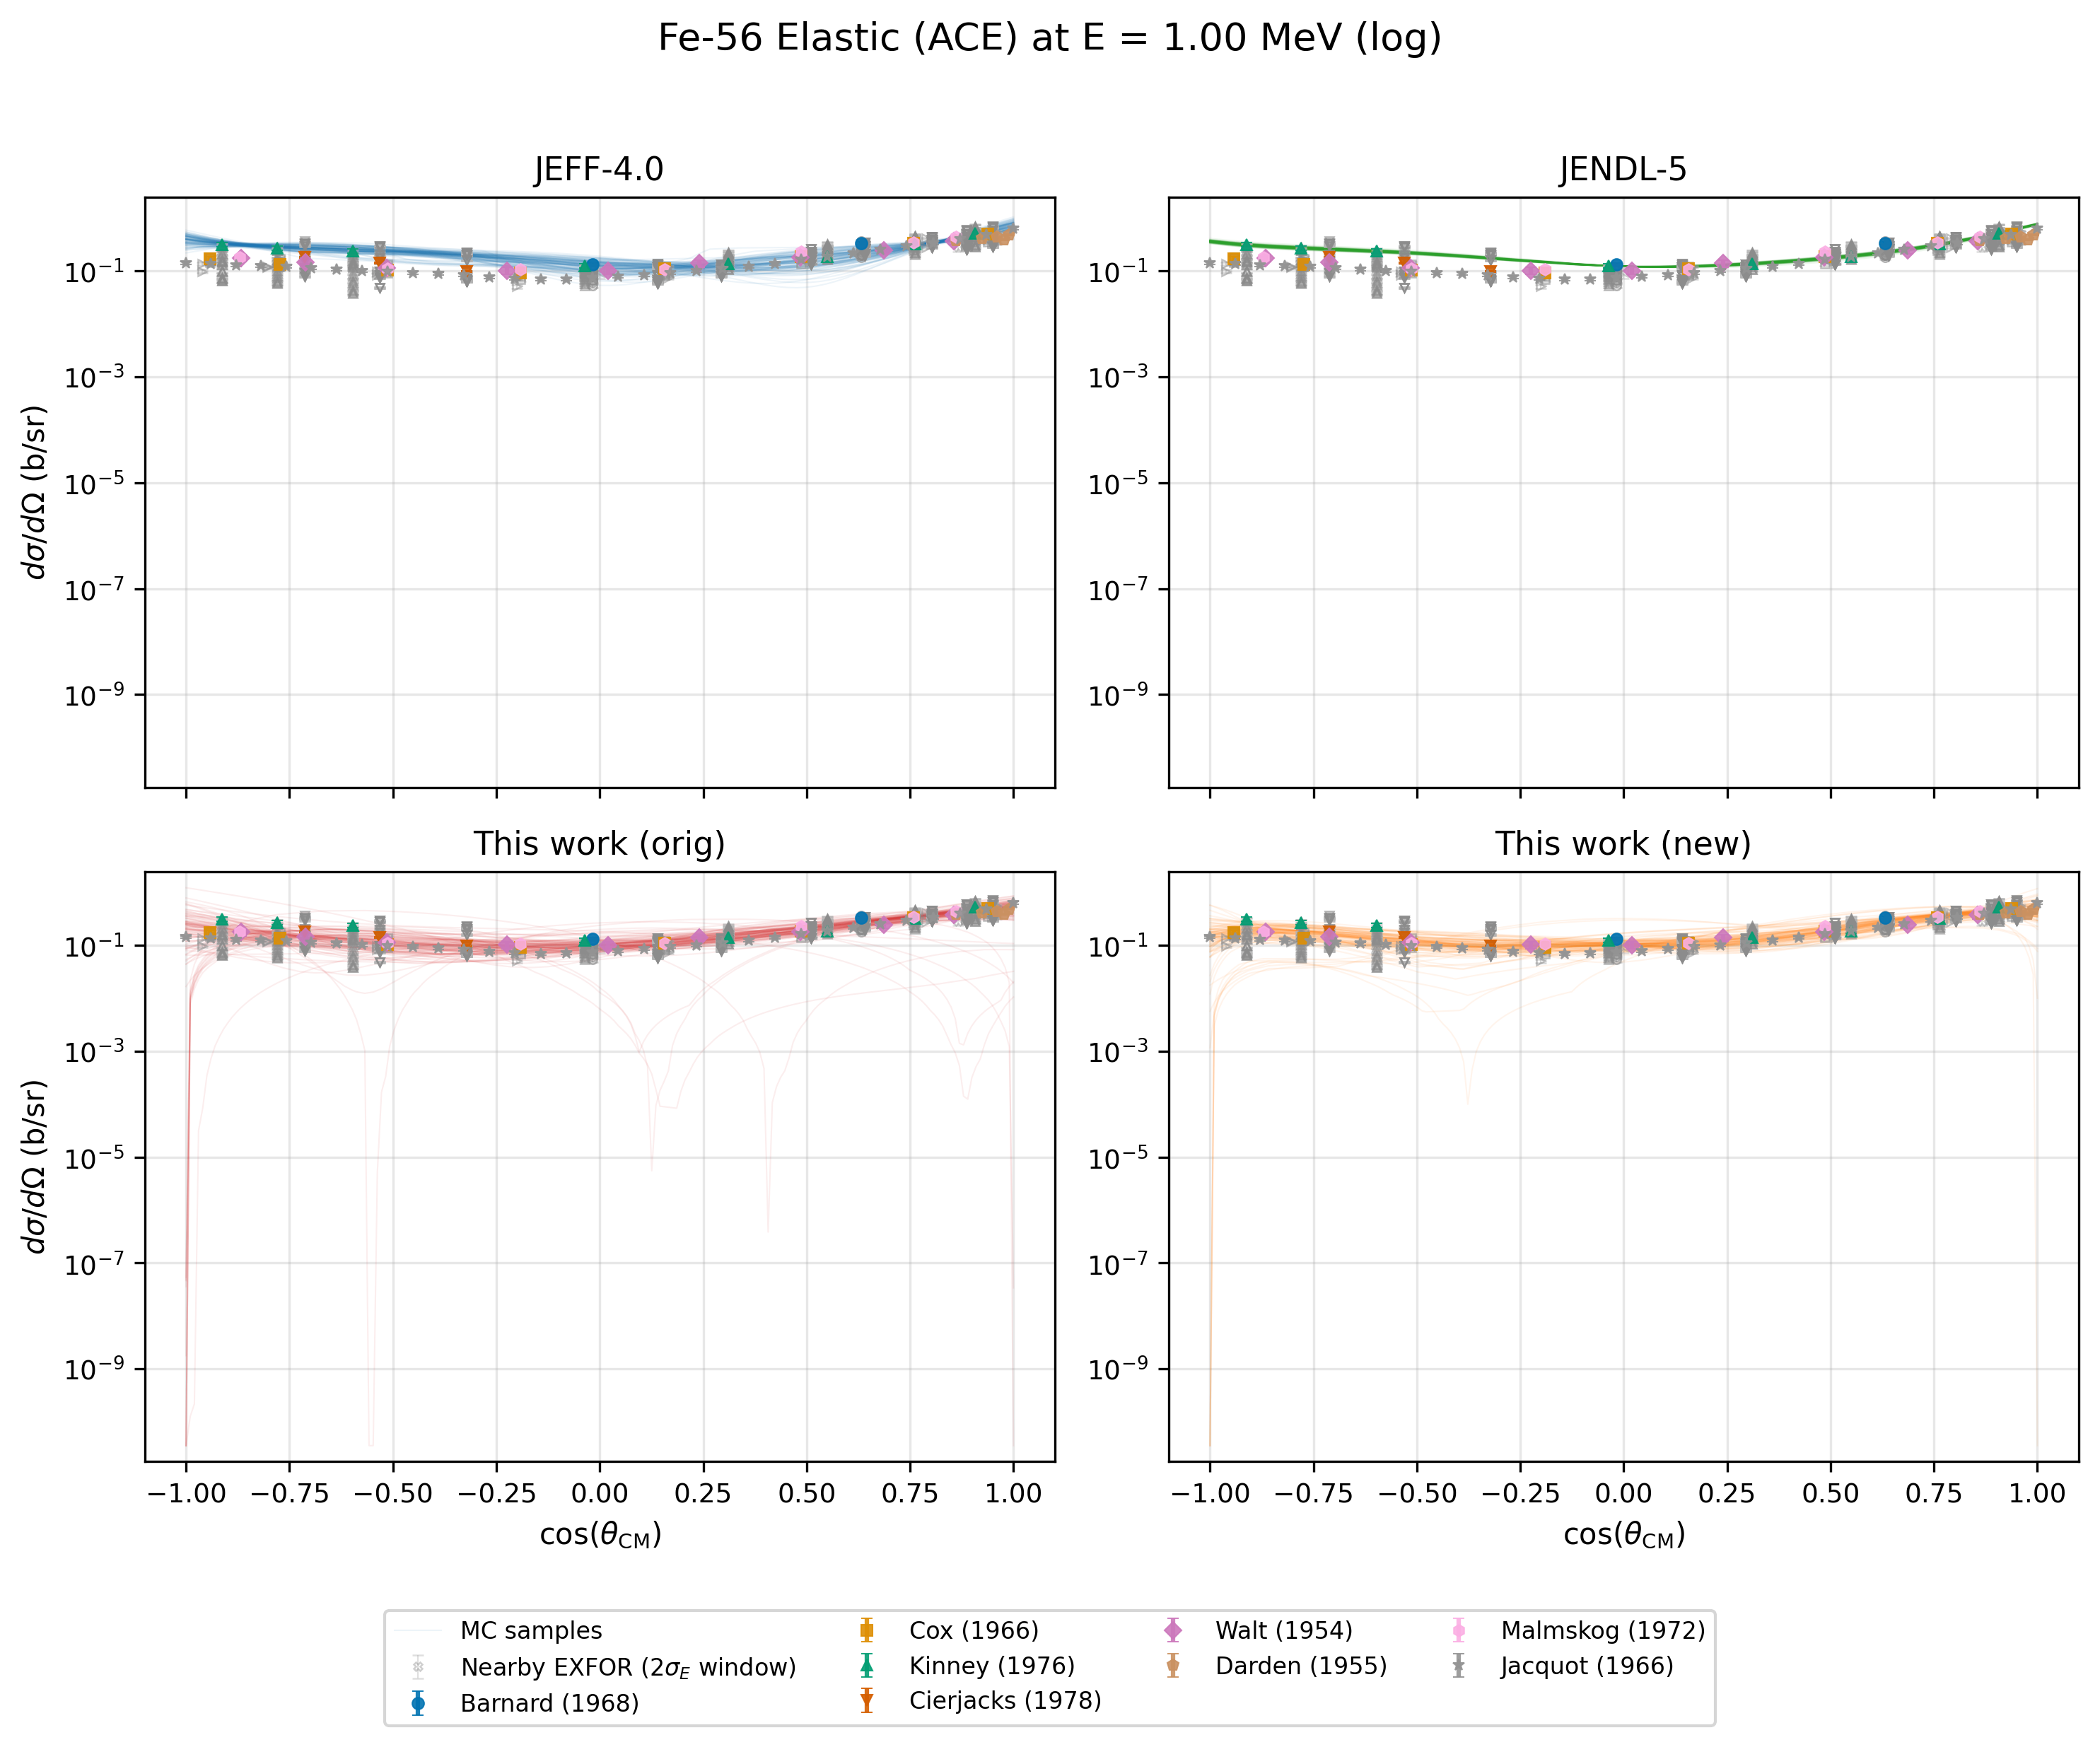

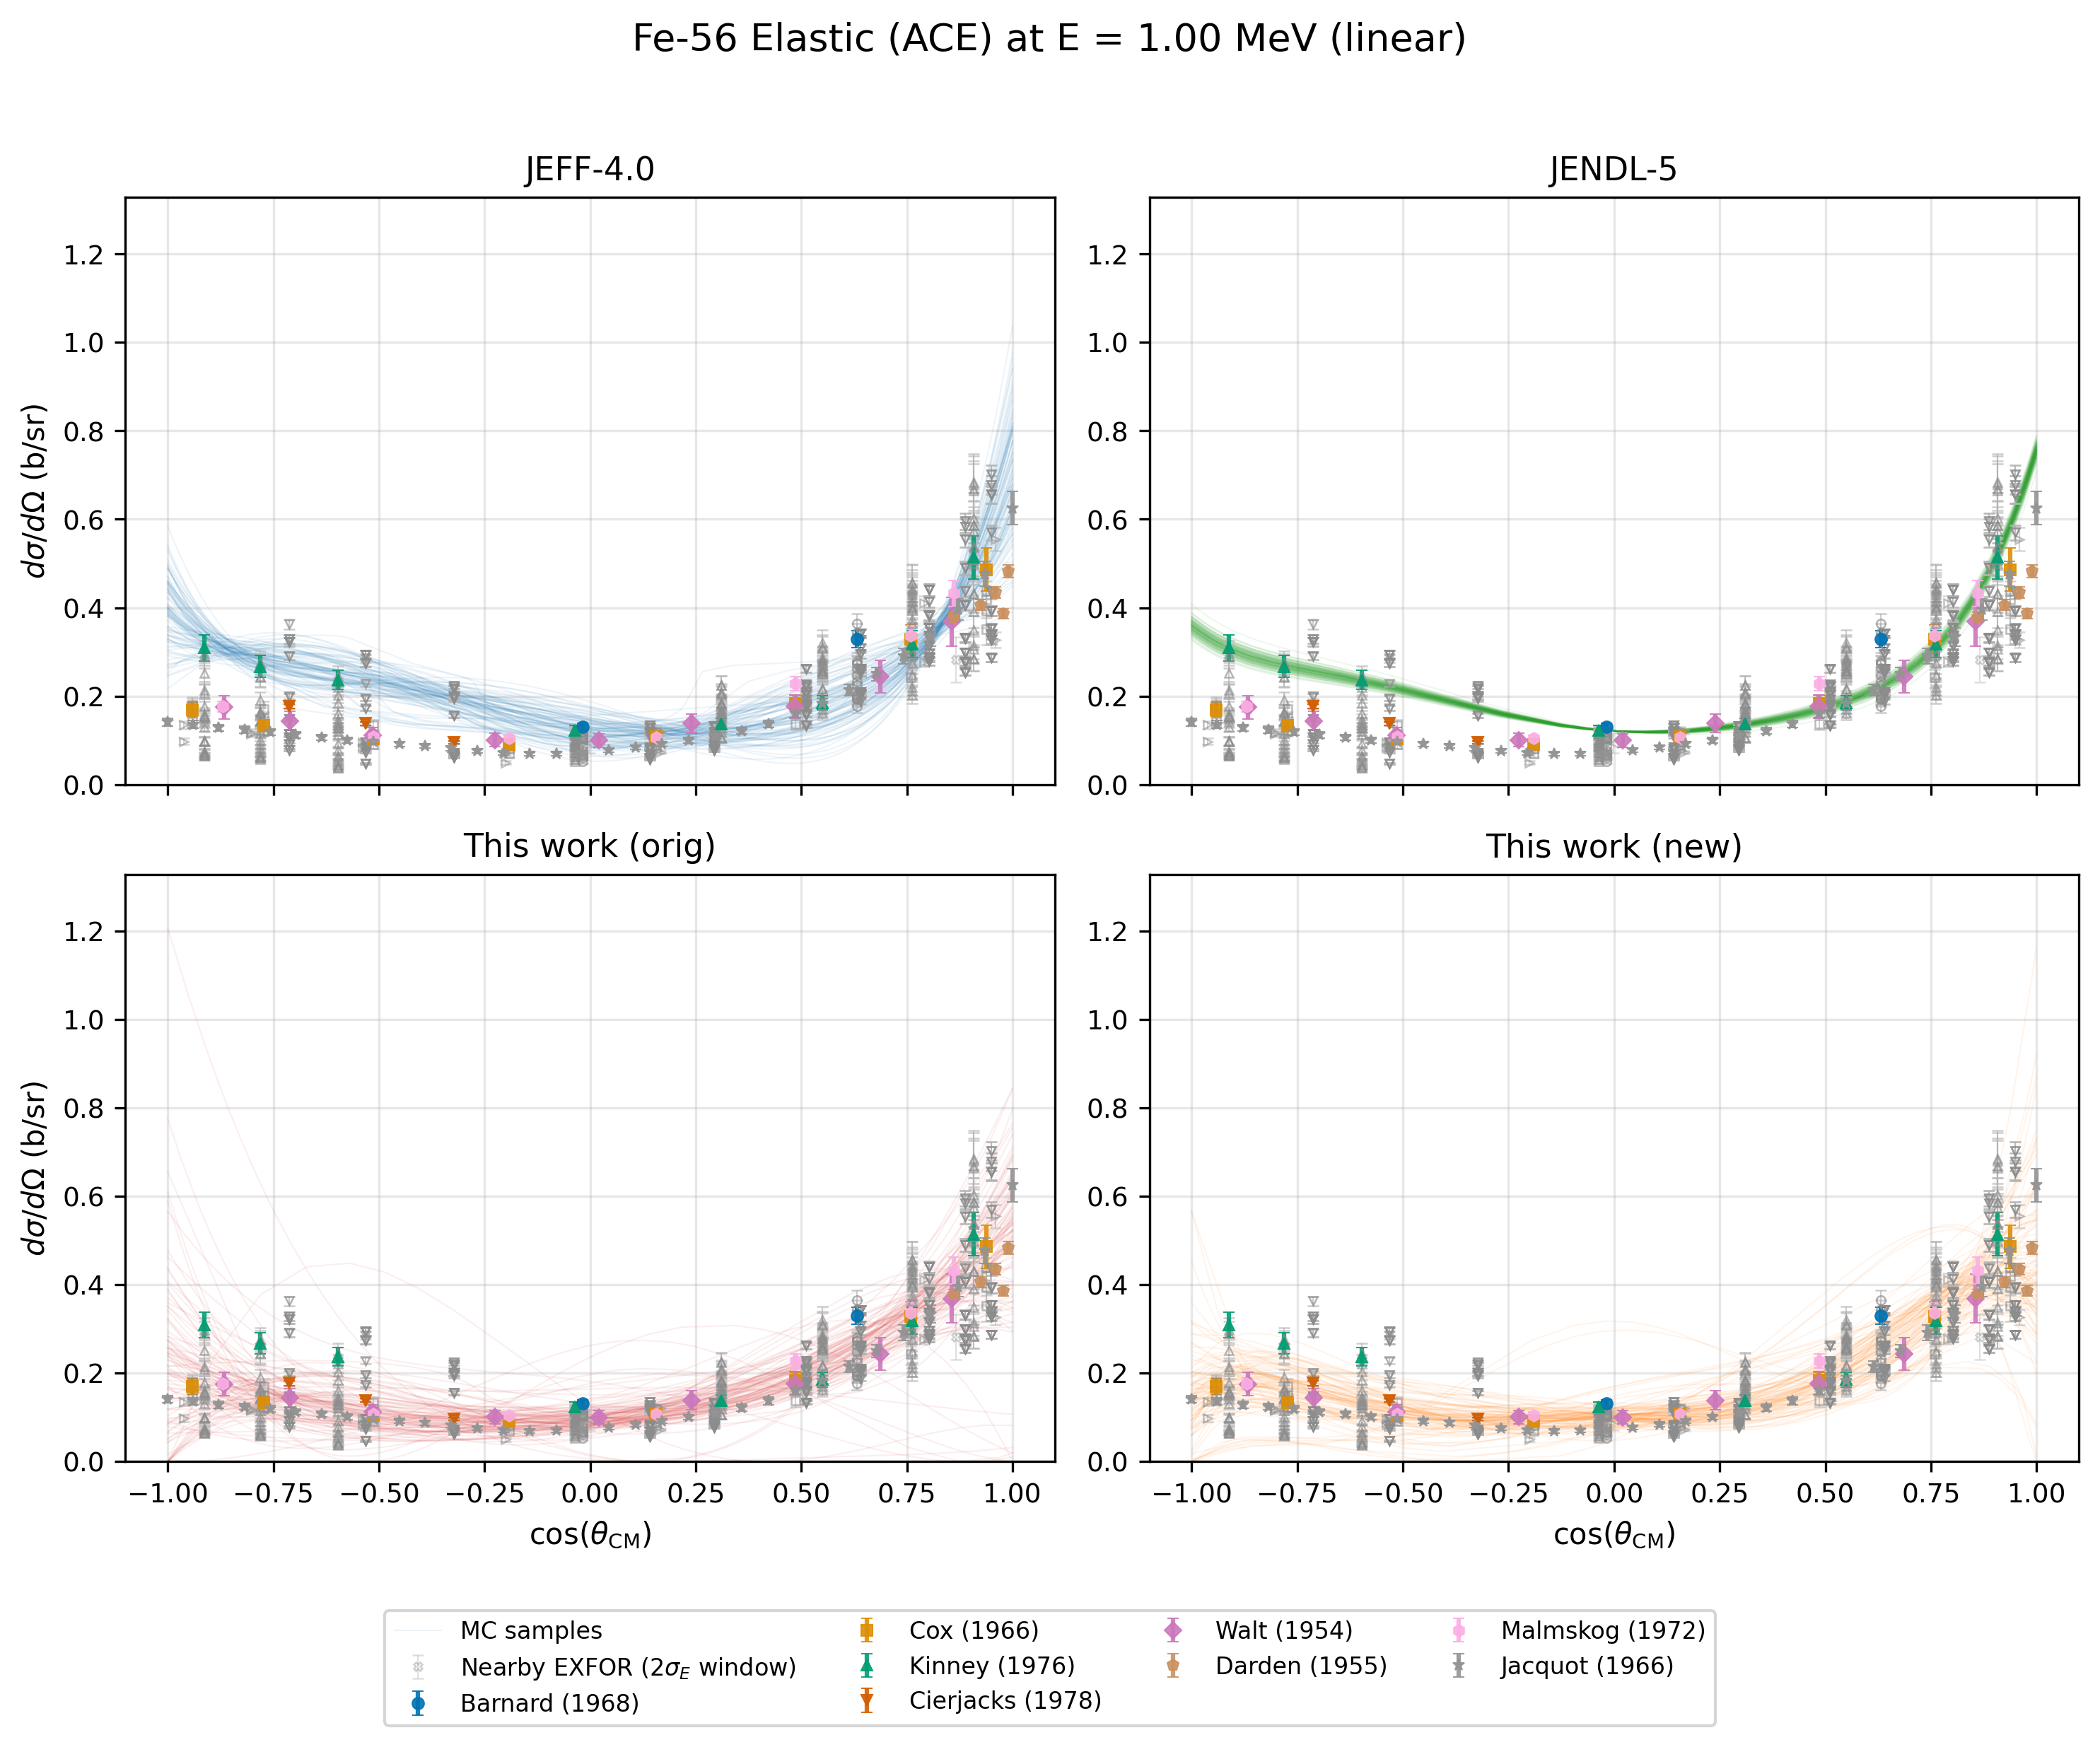

In [10]:
PANEL_LAYOUT = [
    ['JEFF-4.0',         'JENDL-5'],
    ['This work (orig)', 'This work (new)'],
]


def _make_2x2_plot(yscale='log'):
    """Generate 2x2 grid of ACE MC sample curves."""
    fig, axes = plt.subplots(2, 2, figsize=FIGSIZE_2x2, sharex=True)
    fs = FONTSIZES

    for i in range(2):
        for j in range(2):
            key = PANEL_LAYOUT[i][j]
            ax = axes[i, j]
            color = CASE_COLORS[key]

            if key in sample_curves:
                _plot_sample_panel(ax, sample_curves[key], mu_grid, color, key)
            _plot_ext_exfor(ax, ext_exfor_data)
            ax.set_title(key, fontsize=fs['subplot_title'])

    # ---- Shared formatting ----
    all_y = np.concatenate([c.ravel() for c in sample_curves.values() if len(c) > 0])
    all_y_pos = all_y[all_y > 0]

    for i in range(2):
        for j in range(2):
            ax = axes[i, j]
            ax.grid(True, alpha=0.3)
            ax.tick_params(labelsize=fs['tick_label'])
            if yscale == 'log':
                ax.set_yscale('log')
                if len(all_y_pos) > 0:
                    ax.set_ylim(all_y_pos.min() * 0.5, all_y_pos.max() * 2.0)
            else:
                if len(all_y) > 0:
                    ax.set_ylim(all_y.min() * 0.9, all_y.max() * 1.1)
            if i == 1:
                ax.set_xlabel(r'$\cos(\theta_{\rm CM})$', fontsize=fs['axes_label'])
            if j == 0:
                ax.set_ylabel(r'$d\sigma/d\Omega$ (b/sr)', fontsize=fs['axes_label'])

    # Shared legend
    handles, labels = [], []
    seen = set()
    for ax in axes.ravel():
        for h, l in zip(*ax.get_legend_handles_labels()):
            if l not in seen:
                handles.append(h)
                labels.append(l)
                seen.add(l)

    fig.suptitle(f'Fe-56 Elastic (ACE) at E = {TARGET_ENERGY_MEV:.2f} MeV ({yscale})',
                 fontsize=fs['subplot_title'] + 2, y=0.98)
    fig.tight_layout(rect=[0, 0.06, 1, 0.96])
    fig.legend(handles, labels, loc='upper center',
               bbox_to_anchor=(0.5, 0.05), ncol=min(4, len(labels)),
               fontsize=fs['legend'], frameon=True, fancybox=True)
    return fig


for yscale in ['log', 'linear']:
    fig = _make_2x2_plot(yscale=yscale)
    plt.show()